# Forest Cover Type Classification with XGBoost

This notebook builds a multi-class XGBoost model for the Forest Cover Type dataset.

The workflow: 
1. Load and inspect the data  
2. Clean column names  
3. Prepare features and target  
4. Split into train, validation, and test sets  
5. Build preprocessing and XGBoost pipelines  
6. Train a baseline model  
7. Tune XGBoost with randomized search  
8. Compare baseline vs tuned validation performance  
9. Retrain the best model on train + validation  
10. Evaluate once on the untouched test set  
11. Show confusion matrix and feature importance  
12. Save only the final trained pipeline with `joblib`

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

## 1. Project settings

In [ ]:
SETUP = {
    "data_path": "../data/forestcover.csv",
    "target": "cover_type",
    "seed": 42,
    "test_size": 0.20,
    "validation_size_from_train_val": 0.25,
    "num_classes": 7,
    "model_dir": "../models",
    "model_name": "forest_cover_xgb_pipeline.pkl",
}

# n_jobs = -1 is faster since it utilizes 100% of CPU, IF you have strong machine
XGB_BASE = {
    "objective": "multi:softprob",
    "num_class": SETUP["num_classes"],
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": SETUP["seed"],
    "n_jobs": 1,  
}

SEARCH = {
    "n_iter": 20,
    "cv": 3,
    "scoring": "f1_macro",
    "verbose": 2,
    "n_jobs": 1,
}

PARAM_SPACE = {
    "xgb__n_estimators": [200, 300, 500, 700],
    "xgb__max_depth": [4, 6, 8, 10],
    "xgb__learning_rate": [0.03, 0.05, 0.08, 0.10],
    "xgb__subsample": [0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "xgb__min_child_weight": [1, 3, 5, 7],
    "xgb__gamma": [0, 0.1, 0.3, 0.5],
    "xgb__reg_alpha": [0, 0.01, 0.1],
    "xgb__reg_lambda": [1, 1.5, 2, 3],
}

## 2. Small helper functions

In [3]:
def clean_columns(frame):
    frame = frame.copy()
    frame.columns = (
        frame.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return frame


def summarize_missing_values(frame):
    missing_summary = pd.DataFrame({
        "missing_count": frame.isna().sum(),
        "missing_percent": (frame.isna().mean() * 100).round(2),
    })

    return missing_summary.sort_values("missing_count", ascending=False)


def score_multiclass_model(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
    }


def make_xgb_pipeline(prep_step, xgb_params):
    return Pipeline(
        steps=[
            ("prep", prep_step),
            ("xgb", XGBClassifier(**xgb_params)),
        ]
    )

## 3. Load and inspect data

In [4]:
data = pd.read_csv(SETUP["data_path"])
data = clean_columns(data)

print("Shape:", data.shape)
display(data.head())
display(data.dtypes.to_frame("dtype").T)

Shape: (581012, 55)


,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,...,soil_type32,soil_type33,soil_type34,soil_type35,soil_type36,soil_type37,soil_type38,soil_type39,soil_type40,cover_type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,...,soil_type32,soil_type33,soil_type34,soil_type35,soil_type36,soil_type37,soil_type38,soil_type39,soil_type40,cover_type
dtype,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


In [5]:
display(data.describe().T)
display(summarize_missing_values(data).head(20))

print("Duplicate rows:", data.duplicated().sum())

,count,mean,std,min,25%,50%,75%,max
elevation,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
aspect,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
slope,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
horizontal_distance_to_hydrology,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
vertical_distance_to_hydrology,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
horizontal_distance_to_roadways,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
hillshade_9am,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
hillshade_noon,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
hillshade_3pm,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
horizontal_distance_to_fire_points,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0


,missing_count,missing_percent
elevation,0,0.0
aspect,0,0.0
slope,0,0.0
horizontal_distance_to_hydrology,0,0.0
vertical_distance_to_hydrology,0,0.0
horizontal_distance_to_roadways,0,0.0
hillshade_9am,0,0.0
hillshade_noon,0,0.0
hillshade_3pm,0,0.0
horizontal_distance_to_fire_points,0,0.0


Duplicate rows: 0


## 4. Target preparation

In [6]:
target_name = SETUP["target"]

print("Original target distribution:")
display(data[target_name].value_counts().sort_index().to_frame("count"))

print("Original target proportions:")
display((data[target_name].value_counts(normalize=True).sort_index() * 100).round(2).to_frame("percent"))

Original target distribution:


,count
cover_type,
1,211840
2,283301
3,35754
4,2747
5,9493
6,17367
7,20510


Original target proportions:


,percent
cover_type,
1,36.46
2,48.76
3,6.15
4,0.47
5,1.63
6,2.99
7,3.53


In [7]:
# XGBoost expects labels from 0 to num_classes - 1.
# The original Cover_Type labels are 1 to 7, so they are shifted to 0 to 6.
data[target_name] = data[target_name] - 1

print("Shifted target distribution:")
display(data[target_name].value_counts().sort_index().to_frame("count"))

Shifted target distribution:


,count
cover_type,
0,211840
1,283301
2,35754
3,2747
4,9493
5,17367
6,20510


## 5. Feature groups

In [8]:
all_features = [column for column in data.columns if column != target_name]

wilderness_features = [
    column for column in all_features
    if column.startswith("wilderness_area")
]

soil_features = [
    column for column in all_features
    if column.startswith("soil_type")
]

encoded_binary_features = wilderness_features + soil_features

continuous_features = [
    column for column in all_features
    if column not in encoded_binary_features
]

print("Continuous features:", len(continuous_features))
print("Binary encoded features:", len(encoded_binary_features))

Continuous features: 10
Binary encoded features: 44


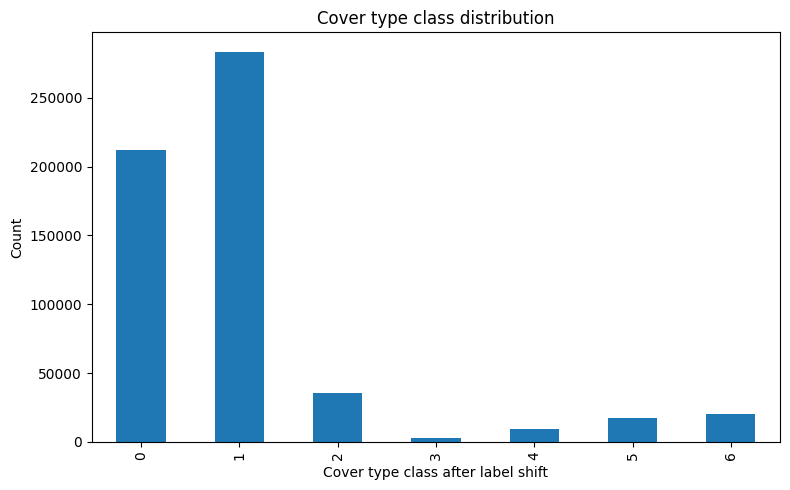

In [9]:
plt.figure(figsize=(8, 5))
data[target_name].value_counts().sort_index().plot(kind="bar")
plt.title("Cover type class distribution")
plt.xlabel("Cover type class after label shift")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 6. Train, validation, and test split

In [10]:
features = data.drop(columns=target_name)
target = data[target_name]

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    features,
    target,
    test_size=SETUP["test_size"],
    random_state=SETUP["seed"],
    stratify=target,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=SETUP["validation_size_from_train_val"],
    random_state=SETUP["seed"],
    stratify=y_train_valid,
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (348606, 54) (348606,)
Validation: (116203, 54) (116203,)
Test: (116203, 54) (116203,)


## 7. Preprocessing

In [11]:
preprocess = ColumnTransformer(
    transformers=[
        ("scale_numeric", StandardScaler(), continuous_features),
        ("keep_binary", "passthrough", encoded_binary_features),
    ],
    remainder="drop",
)

preprocess

,transformers,"[('scale_numeric', ...), ('keep_binary', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## 8. Baseline XGBoost

In [12]:
baseline_pipe = make_xgb_pipeline(
    prep_step=preprocess,
    xgb_params=XGB_BASE,
)

baseline_pipe.fit(X_train, y_train)

baseline_valid_pred = baseline_pipe.predict(X_valid)
baseline_scores = score_multiclass_model(y_valid, baseline_valid_pred)

baseline_scores

{'accuracy': 0.8688243849126098,
 'f1_macro': 0.8519775932545374,
 'precision_macro': 0.8843506886108257,
 'recall_macro': 0.8302273974629332}

In [13]:
print("Baseline validation classification report:")
print(classification_report(y_valid, baseline_valid_pred))

Baseline validation classification report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     42368
           1       0.86      0.90      0.88     56660
           2       0.90      0.91      0.90      7151
           3       0.90      0.88      0.89       549
           4       0.87      0.55      0.67      1899
           5       0.85      0.82      0.84      3474
           6       0.95      0.91      0.93      4102

    accuracy                           0.87    116203
   macro avg       0.88      0.83      0.85    116203
weighted avg       0.87      0.87      0.87    116203



## 9. Hyperparameter tuning

In [14]:
tuning_pipe = make_xgb_pipeline(
    prep_step=preprocess,
    xgb_params=XGB_BASE,
)

search = RandomizedSearchCV(
    estimator=tuning_pipe,
    param_distributions=PARAM_SPACE,
    n_iter=SEARCH["n_iter"],
    scoring=SEARCH["scoring"],
    cv=SEARCH["cv"],
    verbose=SEARCH["verbose"],
    random_state=SETUP["seed"],
    n_jobs=SEARCH["n_jobs"],
)

search.fit(X_train, y_train)

print("Best CV score:", search.best_score_)
print("Best parameters:")
search.best_params_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.1, xgb__learning_rate=0.1, xgb__max_depth=8, xgb__min_child_weight=7, xgb__n_estimators=200, xgb__reg_alpha=0.1, xgb__reg_lambda=1.5, xgb__subsample=0.9; total time= 2.2min
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.1, xgb__learning_rate=0.1, xgb__max_depth=8, xgb__min_child_weight=7, xgb__n_estimators=200, xgb__reg_alpha=0.1, xgb__reg_lambda=1.5, xgb__subsample=0.9; total time= 3.1min
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.1, xgb__learning_rate=0.1, xgb__max_depth=8, xgb__min_child_weight=7, xgb__n_estimators=200, xgb__reg_alpha=0.1, xgb__reg_lambda=1.5, xgb__subsample=0.9; total time= 2.2min
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.5, xgb__learning_rate=0.1, xgb__max_depth=10, xgb__min_child_weight=1, xgb__n_estimators=700, xgb__reg_alpha=0.1, xgb__reg_lambda=1, xgb__subsample=1.0; total time= 3.8min
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.5, 

{'xgb__subsample': 0.9,
 'xgb__reg_lambda': 1.5,
 'xgb__reg_alpha': 0.01,
 'xgb__n_estimators': 700,
 'xgb__min_child_weight': 3,
 'xgb__max_depth': 10,
 'xgb__learning_rate': 0.05,
 'xgb__gamma': 0,
 'xgb__colsample_bytree': 0.8}

## 10. Validation comparison

In [15]:
tuned_pipe = search.best_estimator_

tuned_valid_pred = tuned_pipe.predict(X_valid)
tuned_scores = score_multiclass_model(y_valid, tuned_valid_pred)

validation_results = pd.DataFrame([
    {"experiment": "baseline_xgb", **baseline_scores},
    {"experiment": "tuned_xgb", **tuned_scores},
]).sort_values("f1_macro", ascending=False)

validation_results.round(4)

,experiment,accuracy,f1_macro,precision_macro,recall_macro
1,tuned_xgb,0.9509,0.932,0.9398,0.9246
0,baseline_xgb,0.8688,0.852,0.8844,0.8302


In [16]:
print("Tuned validation classification report:")
print(classification_report(y_valid, tuned_valid_pred))

Tuned validation classification report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     42368
           1       0.95      0.97      0.96     56660
           2       0.95      0.96      0.96      7151
           3       0.91      0.89      0.90       549
           4       0.91      0.84      0.87      1899
           5       0.93      0.92      0.93      3474
           6       0.98      0.96      0.97      4102

    accuracy                           0.95    116203
   macro avg       0.94      0.92      0.93    116203
weighted avg       0.95      0.95      0.95    116203



## 11. Final training on train + validation

In [17]:
final_pipeline = search.best_estimator_

final_pipeline.fit(X_train_valid, y_train_valid)

,steps,"[('prep', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scale_numeric', ...), ('keep_binary', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 12. Final test evaluation

In [18]:
test_predictions = final_pipeline.predict(X_test)
test_scores = score_multiclass_model(y_test, test_predictions)

pd.DataFrame([test_scores]).round(4)

,accuracy,f1_macro,precision_macro,recall_macro
0,0.9554,0.9371,0.9475,0.9275


In [19]:
print("Final test classification report:")
print(classification_report(y_test, test_predictions))

Final test classification report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     42368
           1       0.95      0.97      0.96     56661
           2       0.96      0.96      0.96      7151
           3       0.91      0.87      0.89       549
           4       0.94      0.86      0.90      1899
           5       0.94      0.92      0.93      3473
           6       0.97      0.97      0.97      4102

    accuracy                           0.96    116203
   macro avg       0.95      0.93      0.94    116203
weighted avg       0.96      0.96      0.96    116203



## 13. Confusion matrix

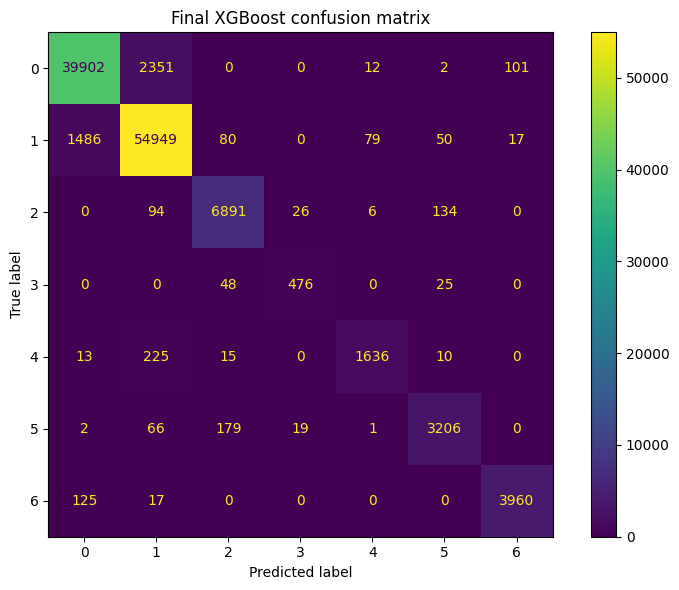

In [20]:
test_cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(8, 6))
display_cm = ConfusionMatrixDisplay(confusion_matrix=test_cm)
display_cm.plot(values_format="d", ax=ax)
ax.set_title("Final XGBoost confusion matrix")
plt.tight_layout()
plt.show()

## 14. Feature importance

In [21]:
ordered_feature_names = continuous_features + encoded_binary_features

xgb_final = final_pipeline.named_steps["xgb"]

importance_table = (
    pd.DataFrame({
        "feature": ordered_feature_names,
        "importance": xgb_final.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_table.head(20))

,feature,importance
0,wilderness_area4,0.142367
1,soil_type39,0.055790
2,soil_type4,0.054114
3,soil_type22,0.049668
4,soil_type2,0.041354
5,soil_type38,0.035727
6,elevation,0.034186
7,soil_type12,0.034011
8,soil_type40,0.033555
9,soil_type37,0.033141


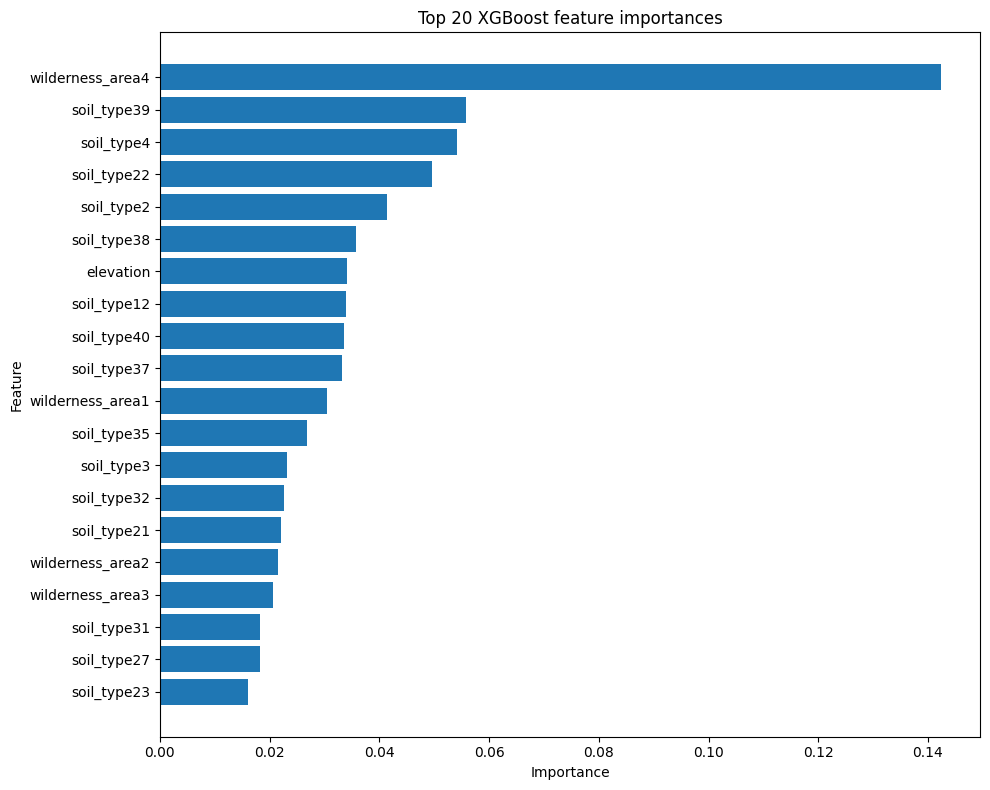

In [22]:
top_features = importance_table.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 20 XGBoost feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 15. Save final model

In [23]:
model_dir = Path(SETUP["model_dir"])
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / SETUP["model_name"]

joblib.dump(final_pipeline, model_path)

print("Saved final pipeline to:", model_path)

Saved final pipeline to: ..\models\forest_cover_xgb_pipeline.pkl


## Final note

The saved object is the full pipeline, not only the XGBoost estimator.  
That means it includes both preprocessing and the trained model.